In [1]:
from astropy.table import Table
from common_functions import reduce, read_sim_path, inject_flux
import glob
import lightkurve as lk
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import os
import pathlib
from pyasassn.client import SkyPatrolClient

/Users/mschochet/anaconda3/envs/asassncnn/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/mschochet/anaconda3/envs/asassncnn/lib/python3.13/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [2]:
os.chdir(pathlib.Path.cwd())
def set_rcparams():
    tab = Table.read('rcparams.txt', format='csv')
    for i in range(len(tab)):
        try:
            plt.rcParams[tab['key'][i]] = float(tab['val'][i])
        except ValueError:
            plt.rcParams[tab['key'][i]] = str(tab['val'][i])
    return
set_rcparams()

In [3]:
client = SkyPatrolClient()

Welcome to ASAS-SN Skypatrol!

Current Deployment Version: 0.6.19 (22 MAY 2025)
Please upgrade your client if not up to date.

We are reprocessing a number of lightcurves in database.
Once finished we should have more complete and higher quality photometry.
Thank you for your patience,
K. Hart (22 MAY 2025)




In [4]:
def pipeline(objid, minimum=False, scaling=False):
    lcs = client.query_list([objid], download=True)
    for lc in lcs.itercurves():
        savedlc = lc
    savedlc_fin = reduce(savedlc)
    return savedlc_fin

In [5]:
lcsave = pipeline(463856975202)

Pulled 1 of 1


In [6]:
simulation_file = glob.glob("files/sim900184.fits")
simulation = read_sim_path(simulation_file[0])
newflux = inject_flux(simulation, lcsave)

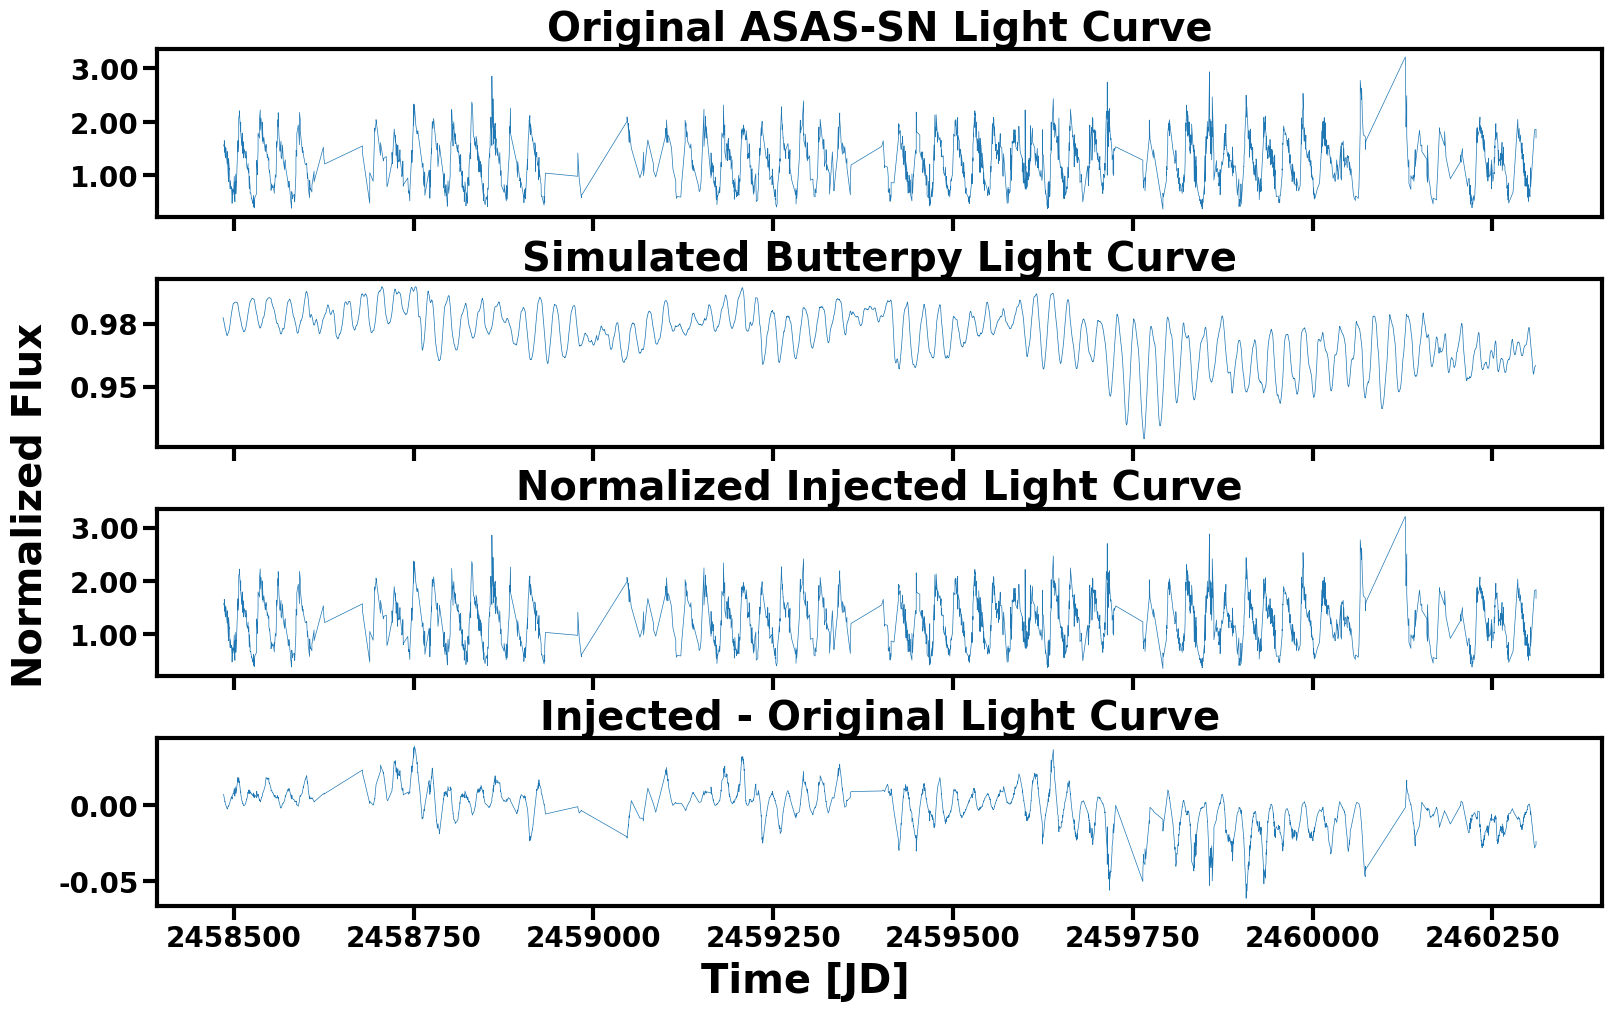

In [19]:

formatter1 = ticker.FormatStrFormatter('%.2f') # Format as integer
formatter2 = ticker.FormatStrFormatter('%.f') # Format as integer

fig, [ax1, ax2, ax3, ax4] = plt.subplots(figsize=(16, 10), ncols = 1, nrows = 4, sharex=True, layout='constrained')


noiseylc = lk.LightCurve(time=lcsave.jd, flux=lcsave.flux)
noiseylc.plot(ax=ax1, xlabel="", ylabel="", rasterized=True)
ax1.yaxis.set_major_formatter(formatter1)
ax1.set_title("Original ASAS-SN Light Curve", weight='bold')

new_sim_lc = lk.LightCurve(time=simulation.time, flux=simulation.flux)
new_sim_lc.plot(ax = ax2, xlabel="", ylabel="", rasterized=True)
ax2.yaxis.set_major_formatter(formatter1)
ax2.set_title("Simulated Butterpy Light Curve", weight='bold')

new_sim_lc2 = lk.LightCurve(time=lcsave.jd, flux=newflux)
new_sim_lc2.plot(ax = ax3, xlabel="", ylabel="", rasterized=True)
ax3.yaxis.set_major_formatter(formatter1)
ax3.set_title("Normalized Injected Light Curve", weight='bold')

new_sim_lc3 = lk.LightCurve(time=lcsave.jd, flux=(newflux-lcsave.flux))
new_sim_lc3.plot(ax = ax4, xlabel="", ylabel="", rasterized=True)
ax4.yaxis.set_major_formatter(formatter1)
ax4.set_title("Injected - Original Light Curve", weight='bold')

plt.locator_params(axis='x', nbins=10)
ax1.xaxis.set_major_formatter(formatter2)
fig.supylabel('Normalized Flux', weight='bold')
fig.supxlabel('Time [JD]', weight='bold')
plt.savefig('lc+inject.pdf')